
# Social Media Sentiment Analysis


In [41]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [42]:
# Load Dataset

df = pd.read_csv(
    "twitter_training.csv",
    header=None
)

df.columns = [
    "ID",
    "Entity",
    "Sentiment",
    "Tweet"
]

df.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [43]:
# Dataset Shape

df.shape

(74682, 4)

In [44]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [45]:
# Missing Values

df.isnull().sum()

,0
ID,0
Entity,0
Sentiment,0
Tweet,686


In [46]:
# Remove Missing Values

df.dropna(inplace=True)

df.isnull().sum()

,0
ID,0
Entity,0
Sentiment,0
Tweet,0


In [47]:
# Duplicate Records

df.duplicated().sum()

np.int64(2340)

In [48]:
# Remove Duplicate Records

df.drop_duplicates(inplace=True)

print(df.shape)

(71656, 4)


In [49]:
# Statistical Summary

df.describe(include="all")

,ID,Entity,Sentiment,Tweet
count,71656.000000,71656,71656,71656
unique,NaN,32,4,69491
top,NaN,TomClancysRainbowSix,Negative,"At the same time, despite the fact that there ..."
freq,NaN,2328,21698,172
mean,6436.437242,NaN,NaN,NaN
std,3742.291368,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3199.000000,NaN,NaN,NaN
50%,6432.500000,NaN,NaN,NaN
75%,9604.000000,NaN,NaN,NaN


In [50]:
# Sentiment Count

df["Sentiment"].value_counts()

,count
Sentiment,
Negative,21698
Positive,19713
Neutral,17708
Irrelevant,12537


In [52]:
# Sentiment Percentage

round(df["Sentiment"].value_counts(normalize=True)*100,2)

,proportion
Sentiment,
Negative,30.28
Positive,27.51
Neutral,24.71
Irrelevant,17.50


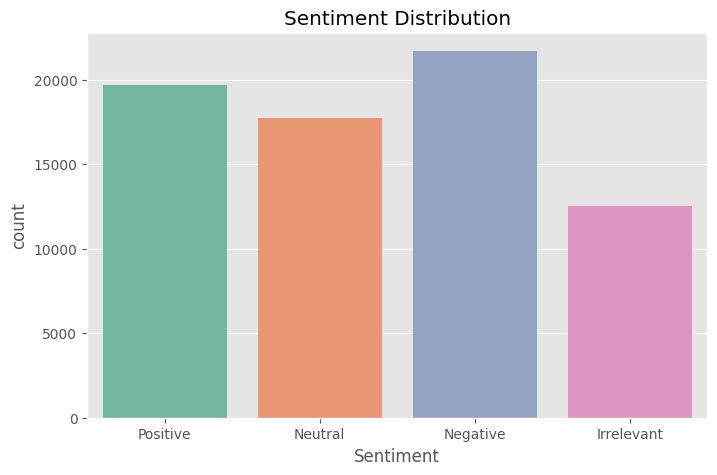

In [53]:
# Sentiment Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x="Sentiment",
    data=df,
    palette="Set2"
)

plt.title(
    "Sentiment Distribution"
)

plt.show()

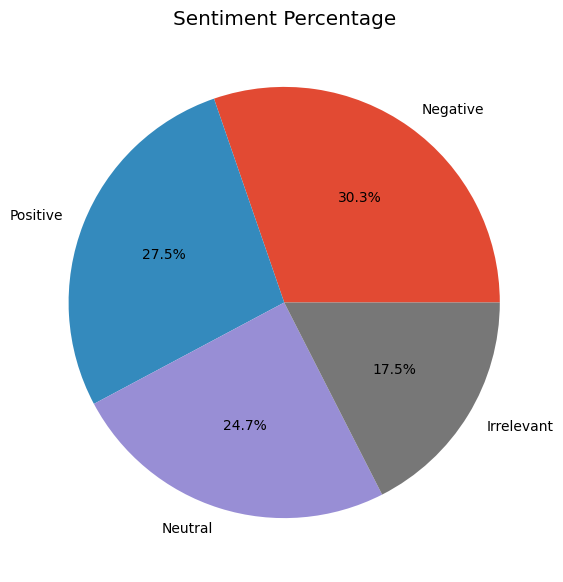

In [54]:
# Pie Chart

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.ylabel("")

plt.title(
    "Sentiment Percentage"
)

plt.show()

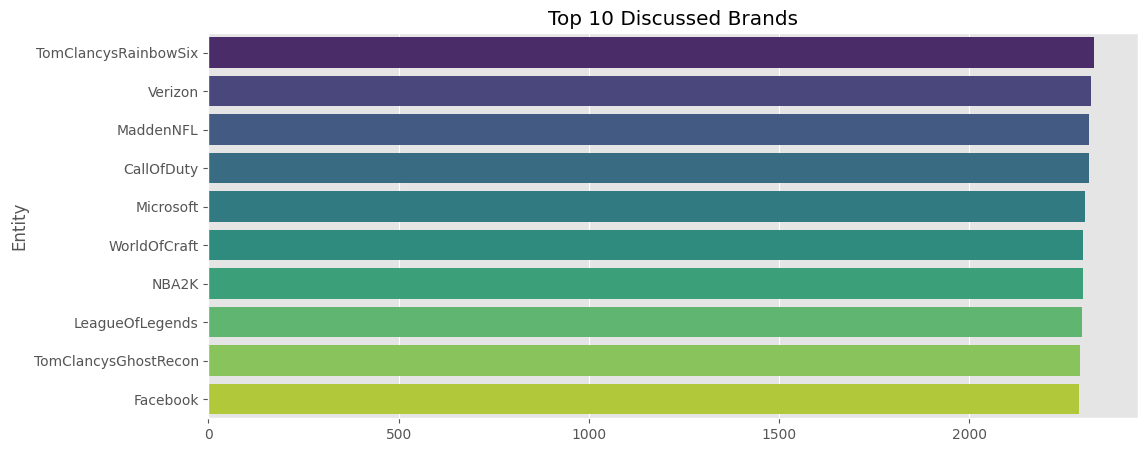

In [55]:
# Top 10 Brands

top_brands = (
    df["Entity"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    palette="viridis"
)

plt.title(
    "Top 10 Discussed Brands"
)

plt.show()

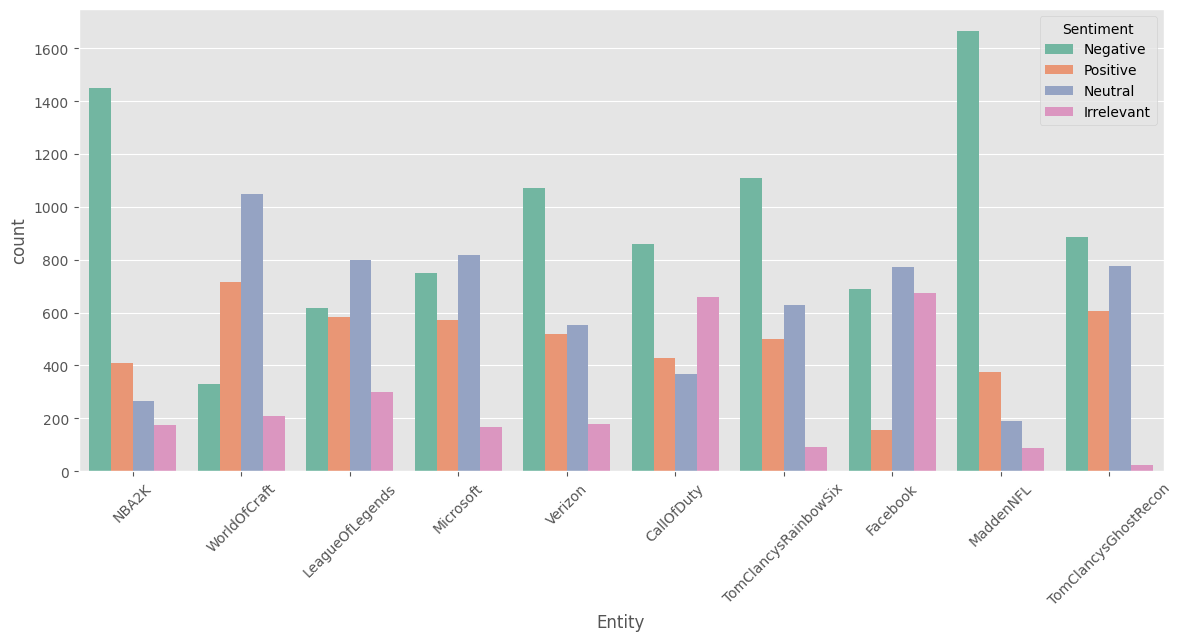

In [56]:
# Brand Wise Sentiment

top_entities = (
    df["Entity"]
    .value_counts()
    .head(10)
    .index
)

brand_df = df[
    df["Entity"].isin(top_entities)
]

plt.figure(figsize=(14,6))

sns.countplot(
    x="Entity",
    hue="Sentiment",
    data=brand_df,
    palette="Set2"
)

plt.xticks(rotation=45)

plt.show()

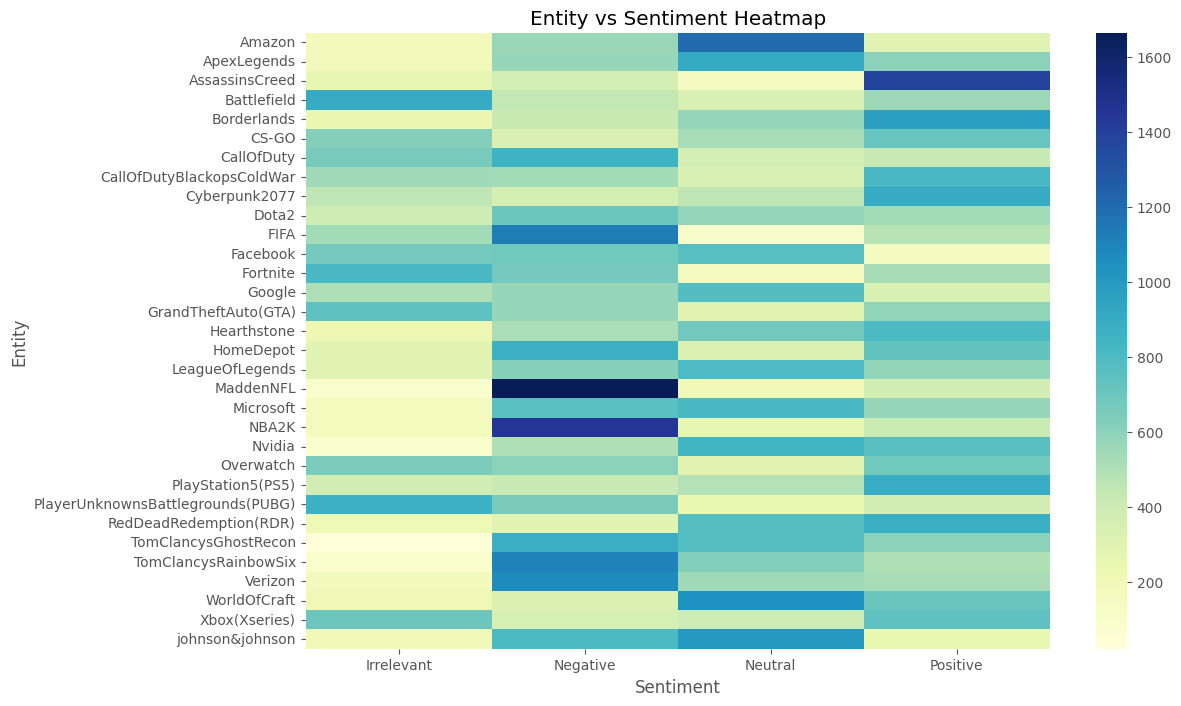

In [57]:
# Heatmap

sentiment_brand = pd.crosstab(
    df["Entity"],
    df["Sentiment"]
)

plt.figure(figsize=(12,8))

sns.heatmap(
    sentiment_brand,
    cmap="YlGnBu"
)

plt.title(
    "Entity vs Sentiment Heatmap"
)

plt.show()

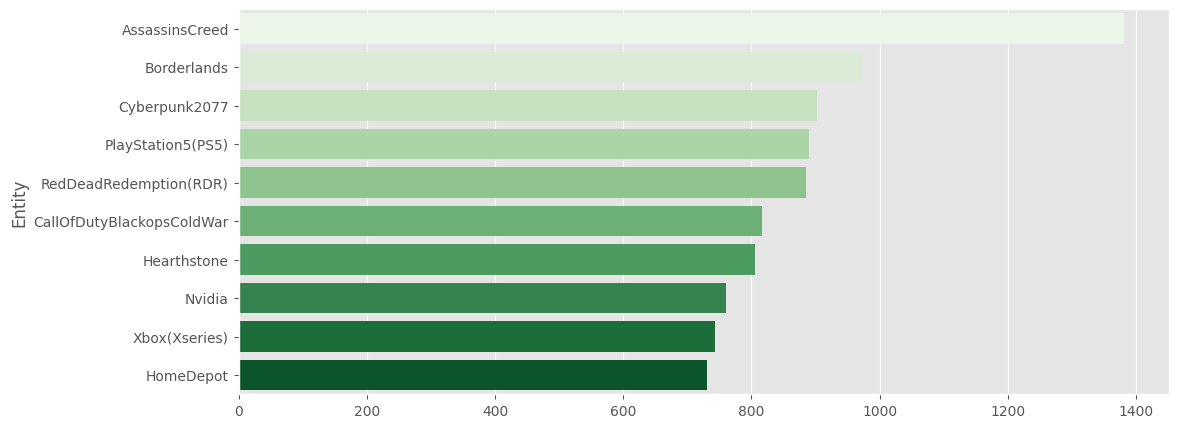

In [58]:
# Positive Brands

positive_df = df[
    df["Sentiment"] == "Positive"
]

top_positive = (
    positive_df["Entity"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_positive.values,
    y=top_positive.index,
    palette="Greens"
)

plt.show()

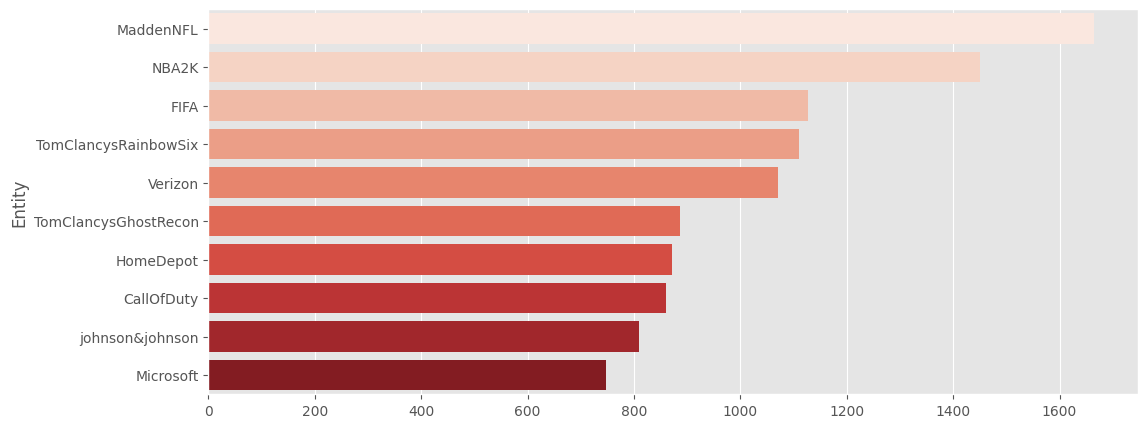

In [59]:
# Negative Brands

negative_df = df[
    df["Sentiment"] == "Negative"
]

top_negative = (
    negative_df["Entity"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_negative.values,
    y=top_negative.index,
    palette="Reds"
)

plt.show()

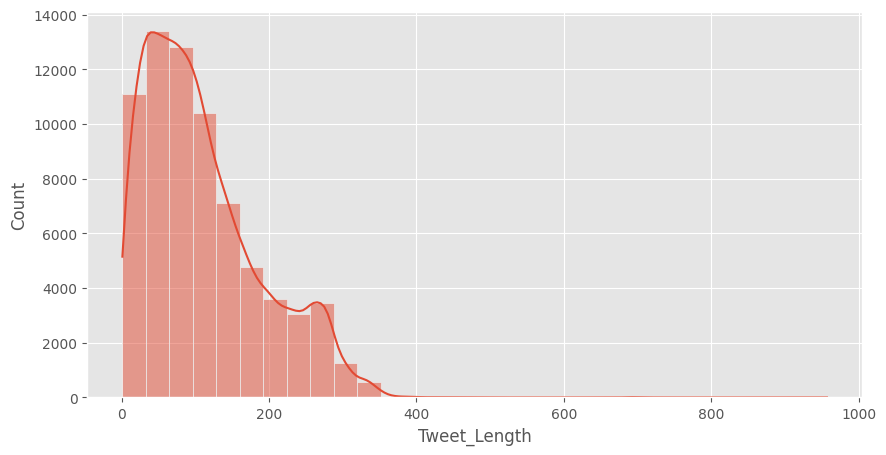

In [60]:
# Tweet Length

df["Tweet_Length"] = (
    df["Tweet"]
    .astype(str)
    .apply(len)
)

plt.figure(figsize=(10,5))

sns.histplot(
    df["Tweet_Length"],
    bins=30,
    kde=True
)

plt.show()

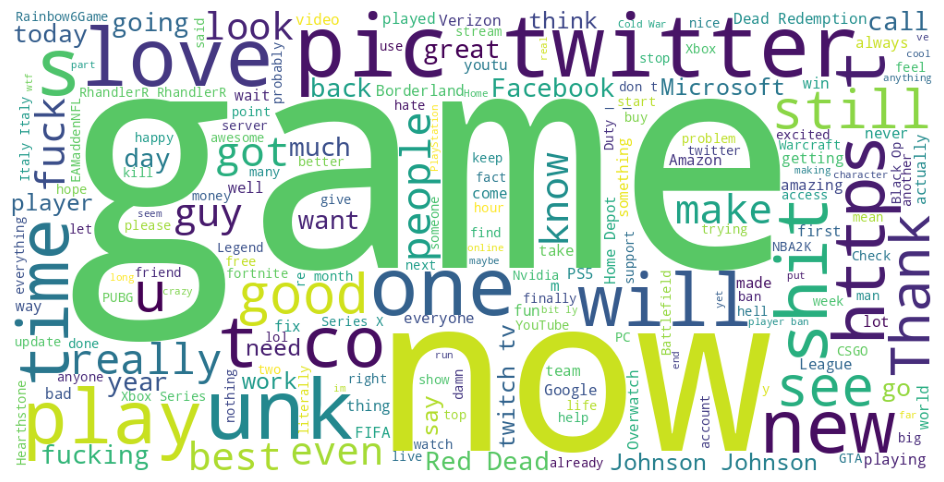

In [61]:
# Word Cloud

text = " ".join(
    df["Tweet"].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [62]:
# Feature & Target

X = df["Tweet"].astype(str)

y = df["Sentiment"]

In [63]:
# TF-IDF

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_vectorized = (
    vectorizer.fit_transform(X)
)

In [64]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
# Logistic Regression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [66]:
# Prediction

y_pred = model.predict(
    X_test
)

In [67]:
# Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy :",
    round(accuracy*100,2),
    "%"
)

Accuracy : 69.73 %


In [68]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

  Irrelevant       0.70      0.54      0.61      2529
    Negative       0.71      0.81      0.76      4383
     Neutral       0.69      0.64      0.66      3543
    Positive       0.68      0.72      0.70      3877

    accuracy                           0.70     14332
   macro avg       0.70      0.68      0.68     14332
weighted avg       0.70      0.70      0.69     14332



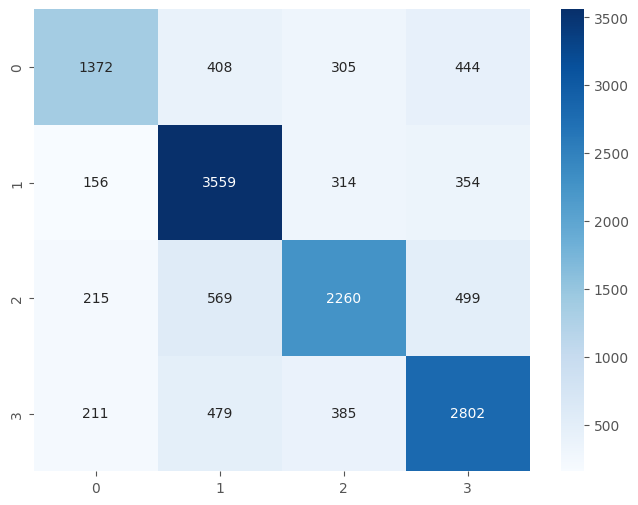

In [69]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()

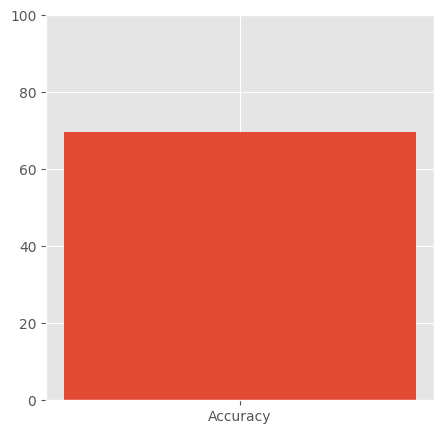

In [70]:
# Accuracy Graph

plt.figure(figsize=(5,5))

plt.bar(
    ["Accuracy"],
    [accuracy*100]
)

plt.ylim(0,100)

plt.show()

In [71]:
# Multiple Predictions

samples = [

    "This game is amazing",

    "I hate this game",

    "This product is average"

]

sample_vector = vectorizer.transform(
    samples
)

predictions = model.predict(
    sample_vector
)

for text, pred in zip(
    samples,
    predictions
):
    print(
        text,
        "=>",
        pred
    )

This game is amazing => Positive
I hate this game => Negative
This product is average => Neutral


# Insights


1. Negative sentiment is dominant.

2. Positive sentiment is also significant.

3. Social media reflects customer opinions.

4. NLP helps automate sentiment classification.

5. Businesses can improve decision making
   using sentiment analysis.


# Conclusion


Model Accuracy : 69.73 %

This project successfully analyzed
social media sentiment using NLP
and Machine Learning.

TF-IDF and Logistic Regression
were used for sentiment classification.

